In [1]:
import Pkg
Pkg.activate("/home/matteo/Projects/OU_inference/")

  Activating project at `~/Projects/OU_inference`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, LinearAlgebra, PyPlot

[ Info: Precompiling DiffusionEvolution [fede2d61-eba6-4945-aa96-3bfe712f026f]
[ Info: Precompiling PyPlot [d330b81b-6aea-500a-939a-2ce795aea3ee]
Precompiling ZygoteColorsExt
  ✓ Zygote → ZygoteColorsExt
  1 dependency successfully precompiled in 39 seconds. 78 already precompiled.
[ Info: Precompiling ZygoteColorsExt [e68c091a-8ea5-5ca7-be4f-380657d4ad79]
┌ Warning: Module Zygote with build ID fafbfcfd-ee33-762d-0000-1e95e187756b is missing from the cache.
│ This may mean Zygote [e88e6eb3-aa80-5325-afca-941959d7151f] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948
[ Info: Skipping precompilation since __precompile__(false). Importing ZygoteColorsExt [e68c091a-8ea5-5ca7-be4f-380657d4ad79].


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x,y,d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
d = 10
nsamples = 1000
T = 50

50

In [7]:
β = 0.05

0.05

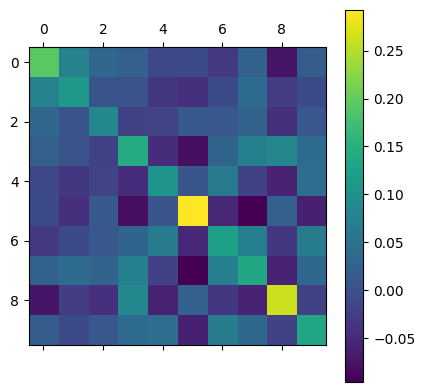

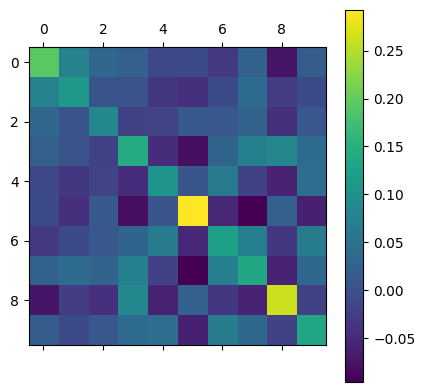

In [8]:
m = randn(d,d)
J = (m * m') * (β/sqrt(d))

figure()
matshow(J)
colorbar()
gcf()

In [9]:
θ = randn(d)
θ ./= norm(θ)
θ .*= 10*d

10-element Vector{Float64}:
  36.46174417784586
   1.5960846786026912
 -52.83935568647542
  28.090428494067833
 -34.267665178252024
  33.1091330083517
 -35.213760984505335
 -33.5548945601647
  20.695606192047105
  -4.710461788233016

In [10]:
γ = 0.04

0.04

In [11]:
x_sim = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T, err_sym=1e-6);

Σ has been symmetrized


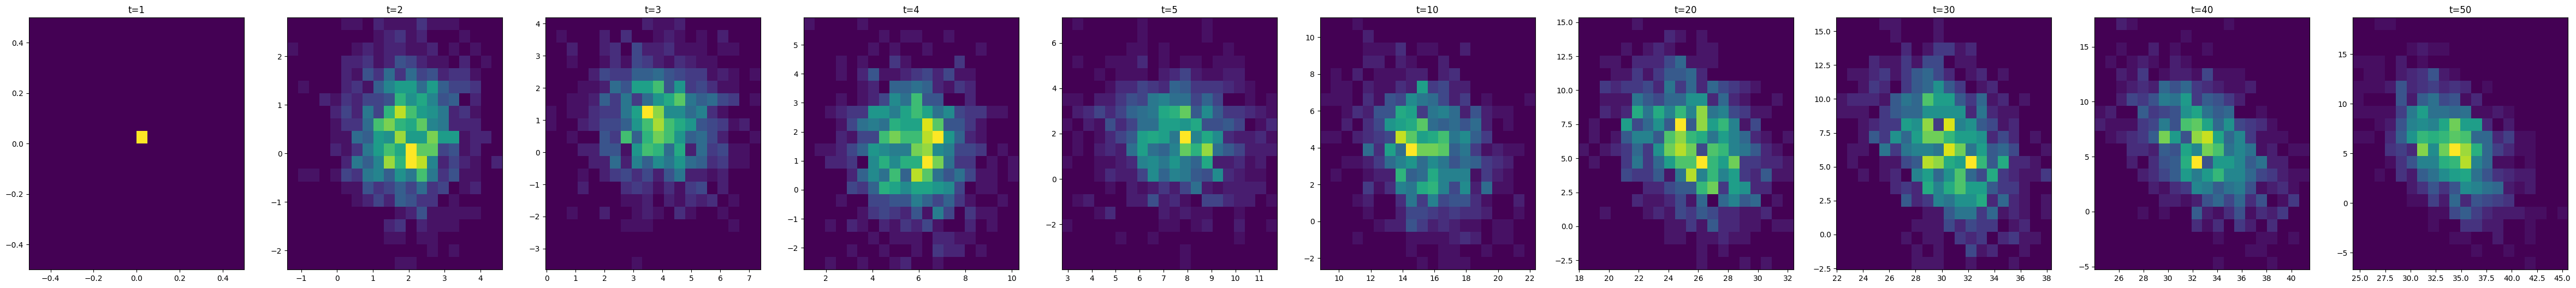

In [12]:
t_view = [1,2,3,4,5,10,20,30,40,50]
fig, ax =subplots(1, length(t_view), 6)
for i in eachindex(t_view)
    ax[i].hist2d(x_sim[1,:,t_view[i]], x_sim[2,:,t_view[i]], bins=20)
    ax[i].set_title("t=$(t_view[i])")
end

In [13]:
t_sample = [1,3,5,10]

4-element Vector{Int64}:
  1
  3
  5
 10

# Single thread

In [14]:
data = collect_data(zeros(d), x_sim[:,:,t_sample .+ 1], fill(1.0, nsamples, length(t_sample)), t_sample)

Data([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], DiffusionEvolution.Sample[DiffusionEvolution.Sample([1.6398070368627535 1.211122225633937 … 1.5313148532580616 0.6839328157870808; 0.6597777182857064 0.275134196869395 … 1.5237413948158922 0.8819416703151046; … ; 3.2801955984515243 4.637243988498186 … 4.0950012808840235 4.437060450515173; -1.5919800510761375 -0.9724420123407 … -1.9529102193707661 -0.6934783822110391], [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001  …  0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001]), DiffusionEvolution.Sample([4.897152883979108 4.60186665153645 … 3.8915516160080648 5.20547887906484; 3.152328529138805 0.07859549784834785 … 1.319076286704421 0.7267476065391284; … ; 12.504881575640928 14.766384579913543 … 14.117611720028991 10.968172951414582; -4.678867835842789 -4.382740381453537 … -4.445623608060201 -5.491853337552011], [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001  …  0.001, 0.0

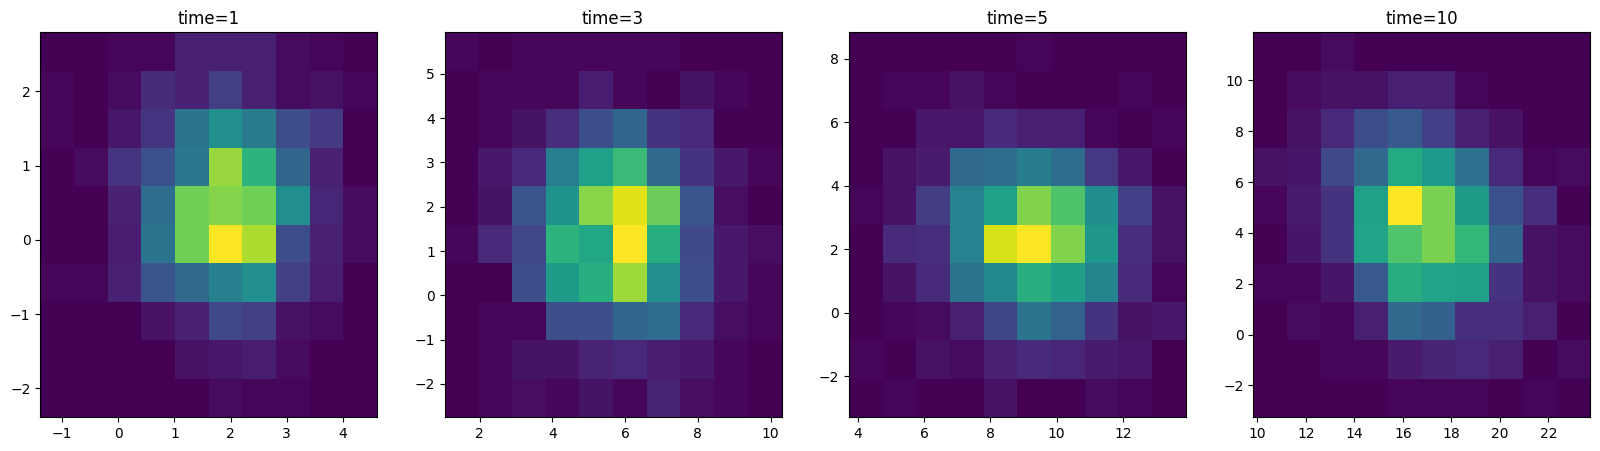

In [15]:
fig, ax = subplots(1, length(data.time), 5)
for i in eachindex(data.time)
    ax[i].hist2d(data.round[i].x[1,:], data.round[i].x[2,:], weights=data.round[i].w)
    ax[i].set_title("time=$(data.time[i])")
end

In [18]:
lambda = 0.01
prior_J = 0.0001
prior_theta = 0.001
prior_gamma = 0.01
eps_conv=1e-7
epsilon = 1e-9

1.0e-9

In [19]:
results = learn_gamma_nlopt_l1(data, initialize=length(data.round), 
    ftol_rel=eps_conv, ftol_abs=eps_conv, xtol_rel=eps_conv, xtol_abs=eps_conv,
    lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, prior_gamma=prior_gamma, epsilon=epsilon)

(minf = 143.80589481617656, minx = [0.2589978222675461, 0.12425595445807235, -0.18918131953346412, -0.011481344403017336, 0.03387896276513483, 0.0531936165180182, -0.22103921680909921, -0.09286464015260339, -0.10696017814252157, 0.15396851305143627  …  6.730418500519623, -22.7794393172107, 18.062600830717464, -21.103519175196944, 29.623908482431478, -38.25454399271565, -25.113093688238227, 33.70523024674619, -13.419614796912308, 0.4362113423049938], status = :FTOL_REACHED, nevals = 1032, x_start = [0.487822964581015, 0.7858031304970267, -0.8103247734839025, -0.9379057037881334, 0.08807661297503673, 0.07844542172777469, 0.27619443266484345, -1.3266491346959643, 0.5984892009512985, -2.0058798666956523  …  4.225566764951029, -14.557928393715638, 11.106837273497014, -15.678206905266448, 22.78492060148259, -27.72901342693511, -18.843379977289672, 25.96459204721494, -11.498760135085462, 0.1])

In [20]:
results.status

:FTOL_REACHED

In [ ]:
lambda = 0.01
prior_J = 0.0
prior_theta = 0.0
epsilon = 1e-7
f_tol = 1e-5
x_tol = 1e-5
g_tol = 1e-3

In [ ]:
results = line_search_optimization(data, initialize=length(data.round), n_points=50, iterations =15,
    gamma_upper = 1.0, gamma_lower=0.01,
    lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, epsilon=epsilon,
    f_tol=f_tol, g_tol=g_tol, x_tol=x_tol)

In [ ]:
plot(results[2])

In [93]:
teacher_ene = compute_energy(data.round[end].x, J, θ)
student_ene = compute_energy(data.round[end].x, results[1][end].minimizer, epsilon);

In [ ]:
scatter(teacher_ene, student_ene)

In [ ]:
lambda = 0.01
prior_J = 0.0
prior_theta = 0.0
prior_gamma = 0.0
epsilon = 1e-6
eps_conv = 1e-9

In [ ]:
opt_results_gamma = learn_gamma_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, prior_gamma=prior_gamma, epsilon=epsilon)

In [ ]:
opt_results_gamma.minx[end]

In [ ]:
de.log_likelihood_gamma(opt_results_gamma.x_start, data, lambda, prior_J, prior_theta, prior_gamma, epsilon)

In [ ]:
opt_results = learn_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, prior_x=prior_x, lambda=lambda, epsilon=epsilon, gamma=γ)

In [ ]:
J_inf = de.compute_J(x, d, epsilon)
matshow(J_inf)
colorbar()

In [22]:
teacher_ene = compute_energy(data.round[end].x, J, θ)
student_ene = compute_energy(data.round[end].x, results.minx, epsilon);

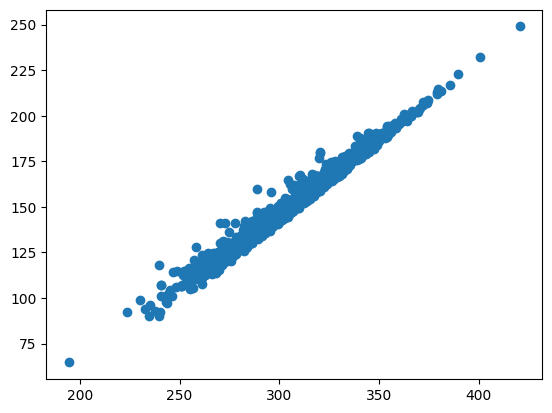

PyObject <matplotlib.collections.PathCollection object at 0x7fbbb5bc4e20>

In [23]:
scatter(teacher_ene, student_ene)

In [ ]:
fig, ax = subplots(1,3,6)
ax[1].scatter(opt_results_gamma.x_start, opt_results_gamma.minx)
ax[2].scatter(opt_results.x_start, opt_results.minx)
ax[3].scatter(opt_results_gamma.minx[1:end-1], opt_results.minx)

In [ ]:
gamma_grid = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0]
ll_val = zeros(length(gamma_grid))
for i in eachindex(gamma_grid)
    r = learn_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
        ftol_rel=eps_conv, prior_x=prior_x, epsilon=epsilon, γ=gamma_grid[i])
    ll_val[i] = r.minf
end

In [ ]:
plot(gamma_grid, ll_val, linestyle="dashed", marker="o")
yscale(:log)
xlabel("gamma")
ylabel("optimal log-likelihood");

In [ ]:
ll_val_gamma = [de.log_likelihood(opt_results_gamma.minx, data, γ, lambda, 0.0, 0.0, epsilon) for γ in gamma_grid]

In [ ]:
plot(gamma_grid, ll_val_gamma, linestyle="dashed", marker="o")
xlabel("gamma")
ylabel("log-likelihood")
yscale(:log)

In [ ]:
de.learn_nlopt_only_gamma(data, x0=opt_results.minx, xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, lambda=lambda, prior_gamma=0.0, epsilon=epsilon) 

In [ ]:
r = de.maximize(data; initialize=0, γ=0.1, xtol_rel=eps_conv, 
    ftol_rel=eps_conv, xtol_abs=eps_conv, ftol_abs=eps_conv, maxtime=-1, maxeval=-1, lambda=lambda,
    prior_x=prior_x, prior_gamma=prior_gamma, epsilon=epsilon, iterations=20);

In [ ]:
r.minγ

In [ ]:
plot(r.ll_iter)
yscale(:log)

In [ ]:
b=de.form_batches(250,30)

In [ ]:
unique(vcat(b...)) |> extrema

# Multithread

In [ ]:
lambda = 0.01
prior_x = 0.01
prior_gamma = 0.01
epsilon = 1e-6
eps_conv = 1e-5

In [ ]:
d_val = [3,5,7,10]

In [ ]:
Threads.@threads for i in eachindex(d_val)
    f = "logs/opt_d$(d_val[i]).txt"
    data = collect_data(zeros(d_val[i]), x_sim[1:d_val[i],:,t_sample], fill(1.0, nsamples, length(t_sample)), t_sample)
    r = iterative_maximization(data; initialize=0, gamma=0.1, xtol_rel=eps_conv, 
        ftol_rel=eps_conv, xtol_abs=eps_conv, ftol_abs=eps_conv, lambda=lambda,
        prior_x=prior_x, prior_gamma=prior_gamma, epsilon=epsilon, iterations=5, logfile=f)
end